# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [1]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 15.6 MB/s eta 0:00:00


In [2]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

¿Por qué utilizar un Algoritmo Genético para este problema?

Elegí utilizar un Algoritmo Genético porque este problema tiene muchas combinaciones posibles de organización de tareas. Al haber 10 tareas, existen millones de órdenes diferentes, por lo que revisarlas todas manualmente o mediante fuerza bruta sería muy poco eficiente.

El Algoritmo Genético permite buscar buenas soluciones de forma inteligente, inspirándose en el proceso de evolución natural. Cada individuo de la población representa una posible planificación de las tareas, y la función de fitness evalúa qué tan buena es esa planificación según el tiempo total que demora la obra.

Las soluciones que obtienen mejores resultados tienen más posibilidades de ser seleccionadas para generar nuevas soluciones. Además, mediante la mutación se introducen pequeños cambios aleatorios que ayudan a explorar alternativas diferentes y evitar que el algoritmo se quede siempre con las mismas opciones.

A medida que avanzan las generaciones, las soluciones suelen mejorar progresivamente, permitiendo encontrar una planificación más eficiente y que respete las restricciones de operarios disponibles.


In [3]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def calcular_makespan(orden_tareas):
    """
    Recibe una lista con el orden de tareas y simula la obra día a día.
    Devuelve (días_totales, es_valido).
    """
    fin_tareas = {}
    operarios_por_dia = {}

    dia_inicio = 0

    for tarea_id in orden_tareas:
        duracion, operarios = TASAS_OBRA[tarea_id]

        # Buscamos el primer día disponible donde quepan los operarios
        dia_actual = dia_inicio
        while True:
            puede_entrar = True
            for d in range(dia_actual, dia_actual + duracion):
                uso_actual = operarios_por_dia.get(d, 0)
                if uso_actual + operarios > MAX_OPERARIOS:
                    puede_entrar = False
                    break

            if puede_entrar:
                break
            dia_actual += 1  # Probamos el día siguiente

        # Asignamos la tarea
        for d in range(dia_actual, dia_actual + duracion):
            operarios_por_dia[d] = operarios_por_dia.get(d, 0) + operarios

        fin_tareas[tarea_id] = dia_actual + duracion

    makespan = max(fin_tareas.values())
    return makespan


def fitness_func(ga_instance, solution, solution_idx):
    """
    PyGAD llama esta función para evaluar cada cromosoma.
    El cromosoma es un vector de prioridades (números 0-9 en distinto orden).
    """
    orden = np.argsort(solution).tolist()

    makespan = calcular_makespan(orden)
    return 1.0 / makespan

In [12]:
ga_instance = pygad.GA(
    num_generations=200,        # Cuántas "generaciones" de evolución
    num_parents_mating=10,      # Cuántos padres se reproducen
    fitness_func=fitness_func,
    sol_per_pop=50,             # Tamaño de la población
    num_genes=NUM_TAREAS,       # Un gen por tarea (10 genes)
    gene_type=float,            # Valores continuos para representar prioridades
    init_range_low=0,
    init_range_high=10,
    mutation_percent_genes=20,  # 20% de genes mutan por generación
    parent_selection_type="tournament",  # Selección por torneo
    crossover_type="single_point",
    mutation_type="random",
    keep_parents=2,             # Los 2 mejores pasan directo a la siguiente gen
    suppress_warnings=True
)

ga_instance.run()
print("Evolución completada")

Evolución completada


       RESULTADO DEL ALGORITMO GENÉTICO

 Orden óptimo de tareas: [0, 1, 2, 6, 3, 4, 8, 5, 9, 7]

 Secuencia de ejecución:
  1. Cimientos       → 5 días, 4 operarios
  2. Muros           → 7 días, 6 operarios
  3. Techo           → 4 días, 5 operarios
  4. Pintura         → 3 días, 2 operarios
  5. Instalaciones   → 6 días, 3 operarios
  6. Revoque         → 5 días, 4 operarios
  7. Electricidad    → 4 días, 2 operarios
  8. Pisos           → 4 días, 3 operarios
  9. Final de obra   → 2 días, 2 operarios
  10. Aberturas       → 2 días, 3 operarios

  Duración total de la obra: 16 días
 Fitness de la mejor solución: 0.0625


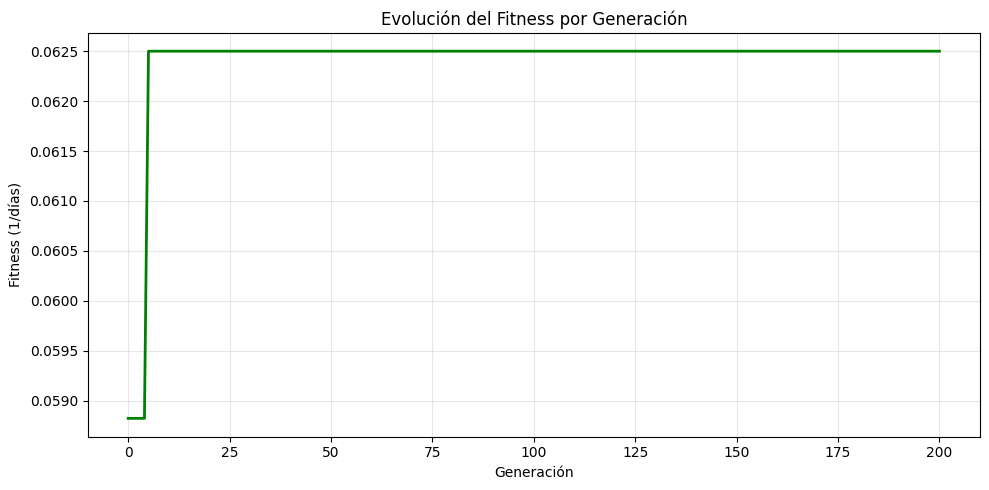

In [14]:
# Mejor solución encontrada
solution, fitness, _ = ga_instance.best_solution()
orden_optimo = np.argsort(solution).tolist()
makespan_optimo = calcular_makespan(orden_optimo)

print("=" * 45)
print("       RESULTADO DEL ALGORITMO GENÉTICO")
print("=" * 45)
print(f"\n Orden óptimo de tareas: {orden_optimo}")

nombres = ["Cimientos","Muros","Techo","Instalaciones",
           "Revoque","Pisos","Pintura","Aberturas",
           "Electricidad","Final de obra"]

print("\n Secuencia de ejecución:")
for i, tarea_id in enumerate(orden_optimo, 1):
    dur, ops = TASAS_OBRA[tarea_id]
    print(f"  {i}. {nombres[tarea_id]:<15} → {dur} días, {ops} operarios")

print(f"\n  Duración total de la obra: {makespan_optimo} días")
print(f" Fitness de la mejor solución: {fitness:.4f}")

# Gráfico de evolución del fitness
plt.figure(figsize=(10, 5))
plt.plot(ga_instance.best_solutions_fitness, color='green', linewidth=2)
plt.title("Evolución del Fitness por Generación")
plt.xlabel("Generación")
plt.ylabel("Fitness (1/días)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print("\n Verificación de uso de operarios por día:\n")
orden = orden_optimo
operarios_por_dia = {}
fin_tareas = {}
dia_inicio = 0

for tarea_id in orden:
    duracion, operarios = TASAS_OBRA[tarea_id]
    dia_actual = dia_inicio
    while True:
        puede_entrar = True
        for d in range(dia_actual, dia_actual + duracion):
            if operarios_por_dia.get(d, 0) + operarios > MAX_OPERARIOS:
                puede_entrar = False
                break
        if puede_entrar:
            break
        dia_actual += 1
    for d in range(dia_actual, dia_actual + duracion):
        operarios_por_dia[d] = operarios_por_dia.get(d, 0) + operarios
    fin_tareas[tarea_id] = dia_actual + duracion

for dia in sorted(operarios_por_dia.keys()):
    uso = operarios_por_dia[dia]
    estado = "✅" if uso <= MAX_OPERARIOS else "❌ VIOLACIÓN"
    print(f"  Día {dia:>2}: {uso:>2} operarios {estado}")


 Verificación de uso de operarios por día:

  Día  0: 10 operarios ✅
  Día  1: 10 operarios ✅
  Día  2: 10 operarios ✅
  Día  3: 10 operarios ✅
  Día  4: 10 operarios ✅
  Día  5: 10 operarios ✅
  Día  6: 10 operarios ✅
  Día  7: 10 operarios ✅
  Día  8: 10 operarios ✅
  Día  9: 10 operarios ✅
  Día 10: 10 operarios ✅
  Día 11:  9 operarios ✅
  Día 12: 10 operarios ✅
  Día 13: 10 operarios ✅
  Día 14: 10 operarios ✅
  Día 15:  7 operarios ✅


## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt